# Club Convergence Analysis

This notebook applies the Phillips–Sul club convergence methodology to panel data.

The analysis follows these main steps:

1. Load the panel dataset.
2. Transform the variables into logarithms.
3. Remove short-run fluctuations using the Hodrick–Prescott (HP) filter.
4. Test for overall convergence using the Phillips–Sul log-t test.
5. Identify convergence clubs.
6. Merge clubs using the Phillips–Sul merging procedure.
7. Visualize the transition paths of the identified convergence clubs.

The dataset is organized in **wide format**, with one row for each country and one column for each time period.

*   List item
*   List item



##Note
The notebook is written in R and saved in Jupyter Notebook (.ipynb) format. It uses the R kernel through IRkernel.

In [ ]:
# Install packages
install.packages("ConvergenceClubs")
install.packages("mFilter")
install.packages("data.table")
install.packages("plyr")
install.packages("tidyverse")
install.packages("tibble")
install.packages("janitor")
install.packages("oglmx")
install.packages("rms")
library(ConvergenceClubs)
library(mFilter)
library(tidyverse)
library(tibble)
library(data.table)
library(plyr)
library(dplyr)
library(janitor)
library(oglmx)
library(rms)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 1. Load the Data

The dataset is imported from a CSV file.

For the club convergence analysis, the data must be arranged in **wide format**:

- Each row represents a country or cross-sectional unit.
- The first column contains the country identifier.
- The remaining columns contain the observations for each time period.

In [ ]:
# Load the panel dataset from the CSV file.
mf <- read.csv('/content/mf percapita.csv')
mf
# The dataset should be in wide format:
# one row per country and one column per time period.

Country,X2000,X2001,X2002,X2003,X2004,X2005,X2006,X2007,X2008,⋯,X2012,X2013,X2014,X2015,X2016,X2017,X2018,X2019,X2020,X2021
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Albania,6.7623,6.9383,7.5069,8.6451,9.4743,10.0417,9.8807,9.8330,10.4972,⋯,9.0079,8.5939,9.5952,9.3100,10.4659,9.2371,8.9873,8.8703,10.0372,9.2651
Algeria,4.8786,5.1242,5.8884,6.4247,6.8152,7.0537,7.3002,8.0267,9.5999,⋯,9.2649,9.0605,9.1473,10.0098,9.8480,9.6630,9.7644,9.5117,8.8443,8.6801
Angola,3.4723,3.7755,3.8609,4.0166,4.0049,4.4871,4.1457,5.2018,6.3529,⋯,6.8087,7.2633,6.8139,7.0170,6.1951,4.8373,4.7132,3.4683,3.4771,2.9961
Argentina,14.2885,13.3852,11.1609,11.5844,12.1163,13.0305,13.2244,14.4005,14.1371,⋯,14.6281,15.9583,15.5034,16.2262,15.8052,17.8194,15.8026,15.6574,15.3567,15.5870
Armenia,6.0084,5.7993,5.4968,5.4856,6.0681,6.6167,7.0957,8.5812,14.5077,⋯,7.0562,7.2676,7.3239,7.2609,6.7448,7.0349,7.3916,7.7749,8.6380,7.3867
Australia,33.2517,34.5897,34.9966,38.2272,40.5506,41.7304,41.6703,42.2755,35.6241,⋯,36.1518,34.0362,34.1449,32.2598,31.9522,34.0499,33.3585,33.2981,31.2669,31.9297
Austria,26.5027,26.0721,25.9629,27.6046,28.2953,27.2065,28.1140,28.6137,28.8325,⋯,25.7112,24.8270,24.4041,23.0712,23.8568,23.1696,23.8277,23.0918,22.7885,25.2238
Azerbaijan,5.1022,5.5962,4.6447,5.3250,6.1451,5.9371,6.4019,6.4249,6.3866,⋯,7.6300,9.1683,8.5970,7.9749,6.9158,7.1038,6.5627,8.0835,8.2539,7.4669
Bahamas,22.6927,19.2553,16.8413,17.3252,15.4212,16.4842,18.7590,17.2973,15.8746,⋯,15.4598,14.0516,14.2274,11.5593,15.3912,16.5621,21.5284,18.5356,13.1864,16.1156


## 2. Log Transformation

The panel data are transformed using the natural logarithm.

The first column, which identifies the countries, is excluded from the transformation because it is not a numerical variable used in the convergence calculation.

In [ ]:
# Transform the numerical panel data using the natural logarithm.
# The first column contains country identifiers and is therefore excluded.
logmf <- log(mf[,-1])

## 3. Remove Short-Run Fluctuations

The Hodrick–Prescott (HP) filter is used to separate the long-run trend from short-run fluctuations in the logged series.

The convergence analysis is performed using the estimated trend component.

The value of `freq` depends on the frequency of the data:

- Annual data: 100
- Quarterly data: 1600
- Monthly data: 14400

In [ ]:
# Remove short-run fluctuations from the logged series using the
# Hodrick–Prescott (HP) filter and retain the estimated trend component.
flogmf <- apply(logmf, 1,
function(x){hpfilter(x, freq=100 , type="lambda")$trend} )
flogmf <- data.frame(Country = mf[,1], t(flogmf), stringsAsFactors=FALSE )
colnames(flogmf) <- colnames(mf)
# Common HP-filter smoothing parameters:
# Quarterly data: 1600
# Annual data: 100
# Monthly data: 14400

## 4. Phillips–Sul Club Convergence Analysis

The next steps apply the Phillips–Sul methodology to test whether the countries in the sample follow a common convergence path.

The analysis consists of:

1. Testing for overall convergence using the log-t test.
2. Identifying convergence clubs if overall convergence is rejected.
3. Examining the resulting club membership and transition paths.
4. Merging clubs where the Phillips–Sul merging procedure indicates that they belong to the same convergence group.

## 5. Phillips–Sul Log-t Test

The first step is to test for overall convergence across all countries.

The Phillips–Sul log-t test is based on the estimated coefficient and its corresponding t-statistic.

The null hypothesis is:

> **H₀: The countries in the sample converge to a common steady-state path.**

If the null hypothesis is rejected, overall convergence is not supported, and the analysis proceeds to identify separate convergence clubs.

In [ ]:
# Calculate the cross-sectional variance measure H required for the Phillips–Sul log-t test.

# Estimate the Phillips–Sul log-t test using a time trimming parameter of 0.333
# and the FQSB HAC method.
H <- computeH(flogmf[,-1], quantity = "H")
round(estimateMod(H, time_trim=0.333, HACmethod = "FQSB"), 3)

# Interpretation:
# H0: There is overall convergence.
# If the estimated beta coefficient is negative and the t-statistic is
# below the critical value of -1.65, H0 is rejected.
# In this case, the analysis proceeds to identify convergence clubs.

beta std.err  tvalue  pvalue 
 -0.607   0.015 -39.451   0.000

## 6. Identification of Convergence Clubs

If overall convergence is rejected, the countries may still converge within smaller groups.

The Phillips–Sul club identification procedure searches for groups of countries that share similar long-run convergence paths.

The resulting object contains information about the identified clubs and their statistical properties.

In [ ]:
# Identify groups of countries that form convergence clubs
# according to the Phillips–Sul club identification procedure.
clubs <- findClubs(flogmf, dataCols=2:23, unit_names = 1, refCol=23,
time_trim=0.333, cstar=0, HACmethod = 'FQSB')
summary(clubs)

Number of convergence clubs: 8
Number of divergent units: 1

        | # of units  | beta     | std.err  | tvalue   | cstar  
-------- ------------- ---------- ---------- ---------- --------
 club1  |   22        |   0.373  |   0.08   |   4.646  |   0    
 club2  |   15        |   0.088  |   0.06   |   1.475  |   0    
 club3  |   21        |   0.176  |   0.045  |   3.941  |   0    
 club4  |   9         |   0.208  |   0.042  |   4.92   |   0    
 club5  |   29        |   0.222  |   0.054  |   4.101  |   0    
 club6  |   15        |   0.366  |   0.123  |   2.973  |   0    
 club7  |   8         |   0.111  |   0.133  |   0.835  |   0    
 club8  |   4         |   1.445  |   0.303  |   4.761  |   0    


### Convergence Club Results

The detailed results of the club identification procedure are displayed below.

In [ ]:
# Display the detailed convergence club results.
print(clubs)

club 1
------------------------------------------------------------------------ 
Kuwait, Singapore, Belgium, Canada, Switzerland, Norway, United Arab 
Emirates, Oman, Israel, New Zealand, Estonia, Mongolia, China, 
Lithuania, Malaysia, Kazakhstan, Turkey, Panama, Paraguay, Bolivia, 
Cote d'Ivoire, Philippines

beta:      0.373 
std.err:   0.0803 
tvalue:    4.6458 
pvalue:    1 
cstar:     0 

club 2
------------------------------------------------------------------------ 
Ireland, Australia, United States of America, Netherlands, Finland, 
Iceland, Bahrain, Sweden, South Korea, Saudi Arabia, Latvia, Romania, 
Argentina, Moldova, Niger

beta:      0.0878 
std.err:   0.0595 
tvalue:    1.4754 
pvalue:    0.9299 
cstar:     0 

club 3
------------------------------------------------------------------------ 
Denmark, Germany, Austria, Cyprus, Brunei Darussalam, Japan, Malta, 
Czech Republic, Hungary, Brazil, Slovakia, Bahamas, Poland, Bulgaria, 
Chile, Russian Federation, Thailand, Namibi

### Transition Paths of the Convergence Clubs

The following plot shows the transition paths associated with the identified convergence clubs.

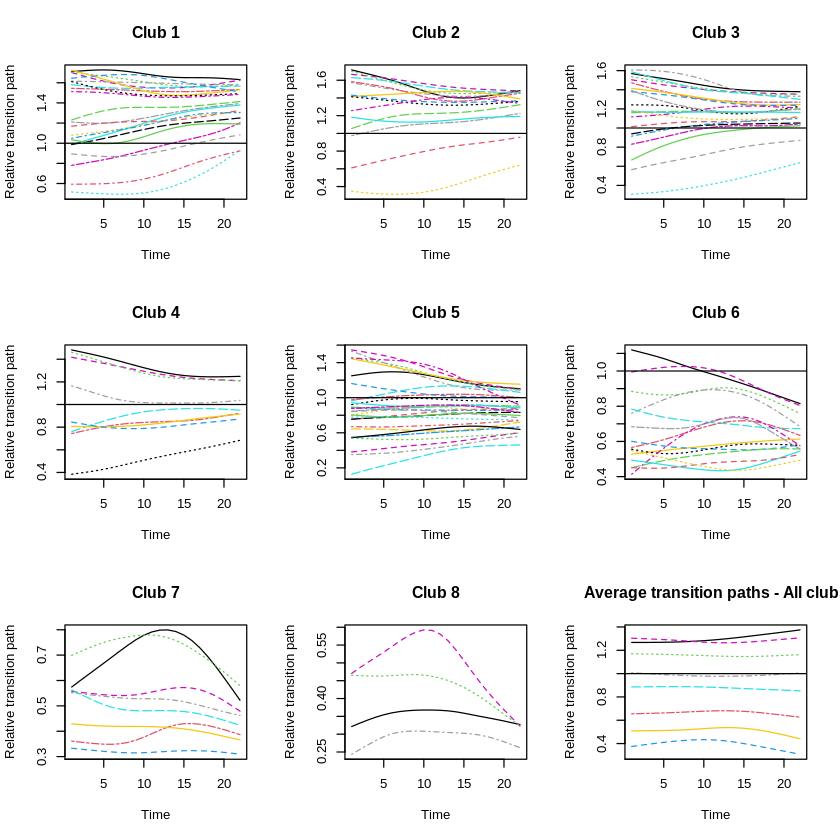

In [ ]:
plot(clubs)

### Average Transition Paths

The following figure displays the average transition path for each identified convergence club.

This provides a clearer comparison of the relative dynamics of the different clubs.

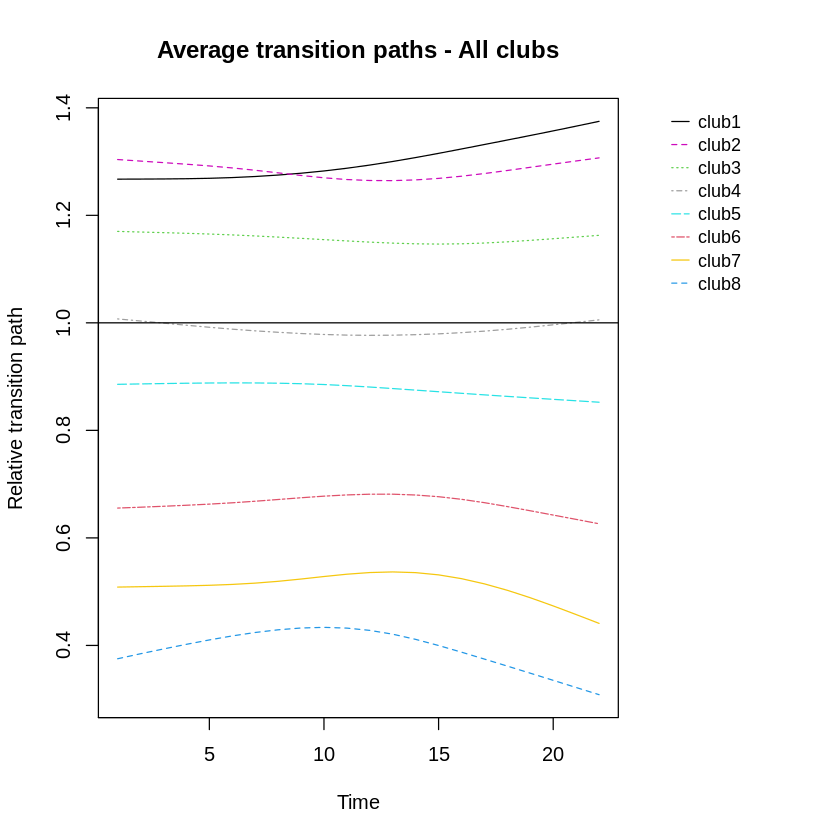

In [ ]:
plot(clubs, clubs=NULL, avgTP = TRUE, legend=TRUE)

## 7. Merging Convergence Clubs

The initial club identification procedure may produce several clubs that can subsequently be tested for possible merging.

The Phillips–Sul merging procedure is applied to determine whether some of the initially identified clubs can be combined into larger convergence groups.

In [ ]:
# Merge the initially identified convergence clubs using
# the Phillips–Sul (PS) merging procedure.
mclubs <- mergeClubs(clubs, mergeMethod='PS')

### Summary of the Merged Clubs

The summary below presents the results after applying the club-merging procedure.

In [ ]:
summary(mclubs)

Number of convergence clubs: 4
Number of divergent units: 1

        | merged clubs       | # of units  | beta     | std.err  | tvalue   
-------- -------------------- ------------- ---------- ---------- ----------
 club1  | clubs: 1, 2, 3, 4  |   67        |  -0.025  |   0.044  |  -0.57   
 club2  | clubs: 5, 6        |   44        |   0.008  |   0.039  |   0.193  
 club3  | clubs: 7           |   8         |   0.111  |   0.133  |   0.835  
 club4  | clubs: 8           |   4         |   1.445  |   0.303  |   4.761  


### Detailed Results After Club Merging

The detailed results for the merged convergence clubs are displayed below.

In [ ]:
print(mclubs)

club 1
------------------------------------------------------------------------ 
Kuwait, Singapore, Belgium, Canada, Switzerland, Norway, United Arab 
Emirates, Oman, Israel, New Zealand, Estonia, Mongolia, China, 
Lithuania, Malaysia, Kazakhstan, Turkey, Panama, Paraguay, Bolivia, 
Cote d'Ivoire, Philippines, Ireland, Australia, United States of 
America, Netherlands, Finland, Iceland, Bahrain, Sweden, South Korea, 
Saudi Arabia, Latvia, Romania, Argentina, Moldova, Niger, Denmark, 
Germany, Austria, Cyprus, Brunei Darussalam, Japan, Malta, Czech 
Republic, Hungary, Brazil, Slovakia, Bahamas, Poland, Bulgaria, Chile, 
Russian Federation, Thailand, Namibia, Viet Nam, Indonesia, Bangladesh, 
Slovenia, France, United Kingdom, Lebanon, Algeria, Ukraine, Nicaragua, 
Dominican Republic, Kenya

beta:     -0.0248 
std.err:   0.0435 
tvalue:   -0.5699 
pvalue:    0.2844 

club 2
------------------------------------------------------------------------ 
Croatia, Greece, Spain, Portugal, Belarus,

### Transition Paths of the Merged Clubs

The following plot shows the transition paths after the convergence clubs have been merged.

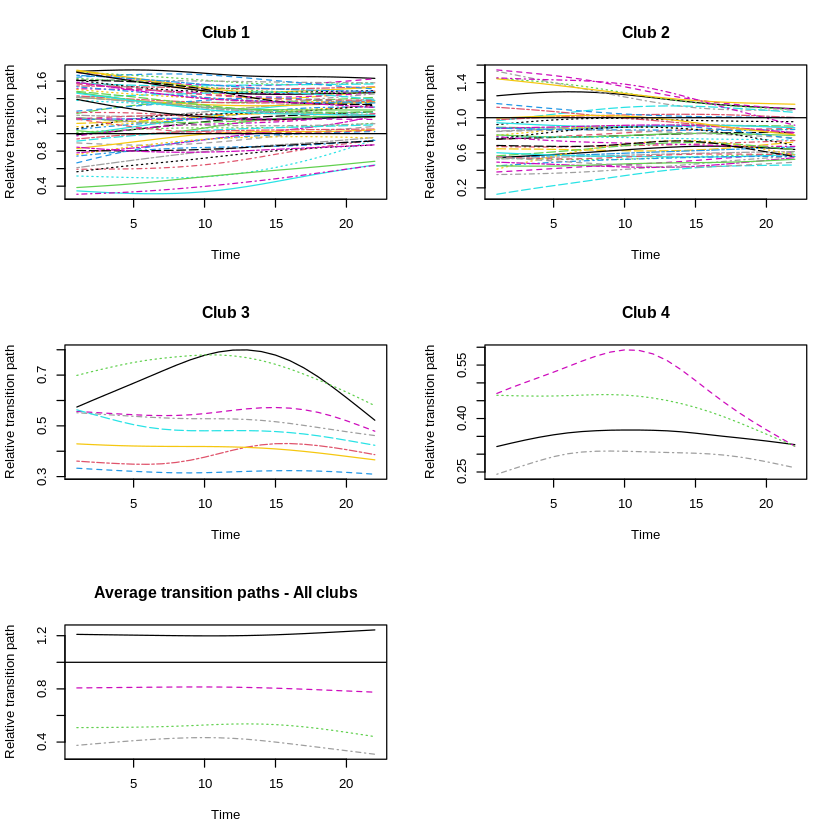

In [ ]:
plot(mclubs)

### Average Transition Paths of the Merged Clubs

The final figure presents the average transition path for each merged convergence club, together with the corresponding legend.

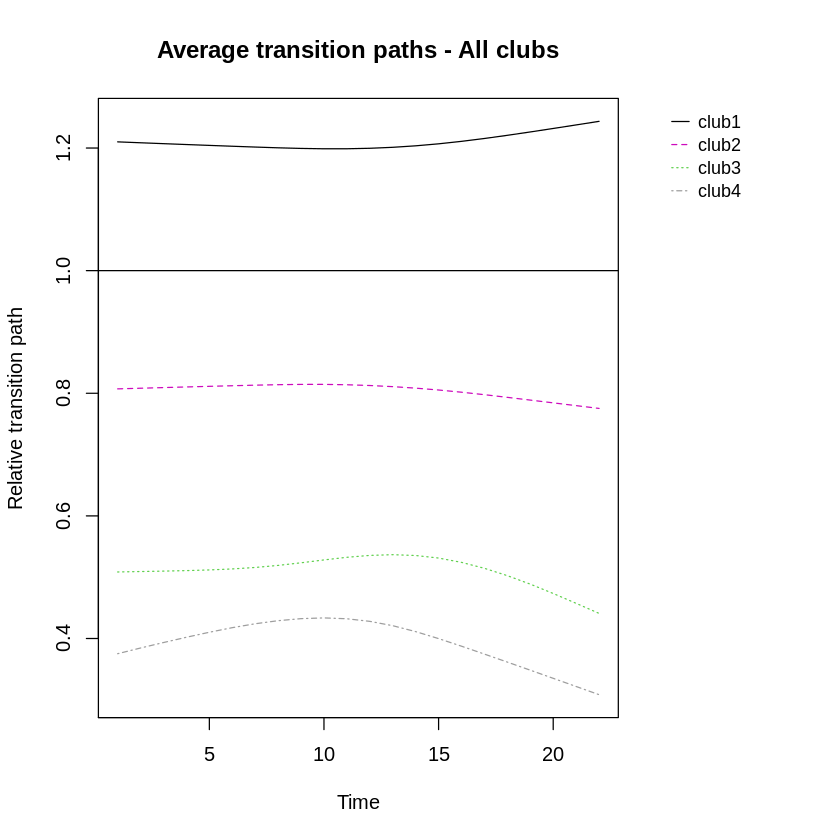

In [ ]:
plot(mclubs, clubs=NULL, avgTP = TRUE, legend=TRUE)